# PyTorch Deep Learning: MNIST Classification

A deep learning coursework project exploring neural network architectures and training strategies on the MNIST handwritten digit dataset.

## Project Overview
- **Dataset:** MNIST (60,000 training / 10,000 test images, 10 classes)
- **Models:** Fully Connected Network (FCNet) vs. Convolutional Neural Network (CNN)
- **Experiments:**
  1. Overfitting analysis — demonstrating train/validation divergence
  2. L2 regularisation sweep — finding the optimal weight decay
  3. Learning curve experiment — validation error vs. training set size
  4. Architecture comparison — FCNet vs. CNN on identical tasks

**Key result:** CNN achieves ~3.5% validation error at full training size, outperforming the FCNet baseline across all dataset sizes.

## Set up dataset

You may choose any of the datasets included with Pytorch, or used in the course so far (including, for example, the percolation data). (It is a free country and you may use any other data you wish.)

A safe choice would be either the MNIST data or the MNIST-fashion data, which is a drop-in replacement for MNIST (same size data format, same number of classes, same number of training and test examples).

A more interesting choice would be CIFAR-10

In setting up the data, you should set up a training set and a test set. The test set should be large enough to give a reasonably accurate assessment of the error-rate (or loss) of your models: preferably at least 10,000 examples.

For the learning curve experiment (below), you will need to construct training sets of different sizes, with the largest at least 10 times the smallest. For the MNIST data, for example, your smallest training set might be 500, with sizes 500, 1000, 2000, 4000, 8000, 16000, 32000, and perhaps 60000 if you have time. (You get no extra marks for doing very long experiments.)

## Set up model

Set up a Pytorch model (you may find it helpful to keep it simple and fast to train). Train on an intermediate-sized dataset (if you are using MNIST, say 2000 or 4000).


Plot the loss and error rate as a function of training epochs.


###  1.  Assessment of initial model:    ***12 marks***

Ensure that your model is complex enough to *overfit* the training data: that is the loss/error-rate on the training set should be below your target loss/error-rate, and the loss/error-rate on the validation set should be higher than this (preferably higher than your target error-rate).

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import math

torch.manual_seed(42)
np.random.seed(42)

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [2]:
# Transformations using mean and std of the dataset.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Download MNIST training/test datasets
train_dataset = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

# Data loader function for different training set sizes.
def get_subset_loader(dataset, subset_size, batch_size=64):
    indices = np.random.choice(len(dataset), subset_size, replace=False)
    subset = Subset(dataset, indices)
    loader = DataLoader(subset, batch_size=batch_size, shuffle=True)
    return loader

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:00<00:00, 17.2MB/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 455kB/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:00<00:00, 4.21MB/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 6.63MB/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



In [3]:
# Implementation of fully connected network.
def FCNet(dropout_prob=0.0):
    return nn.Sequential(
        nn.Flatten(),                    
        nn.Linear(28*28, 256),
        nn.ReLU(),
        nn.Dropout(dropout_prob),
        nn.Linear(256, 128),
        nn.ReLU(),
        nn.Linear(128, 10)
    )

In [4]:
def train_model(model, train_loader, test_loader, num_epochs=10, learning_rate=0.01, weight_decay=0.0):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    
    train_losses, test_losses = [], []
    train_errors, test_errors = [], []

    # Train set
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct_train += (preds == labels).sum().item()
            
        train_loss = running_loss / len(train_loader.dataset)
        train_error = 1.0 - correct_train / len(train_loader.dataset)
        
        train_losses.append(train_loss)
        train_errors.append(train_error)
        
        # Validation test set
        model.eval()
        running_loss_test = 0.0
        correct_test = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                running_loss_test += loss.item() * images.size(0)
                preds = outputs.argmax(dim=1)
                correct_test += (preds == labels).sum().item()
                
        test_loss = running_loss_test / len(test_loader.dataset)
        test_error = 1.0 - correct_test / len(test_loader.dataset)
        
        test_losses.append(test_loss)
        test_errors.append(test_error)
        
        print(f"Epoch [{epoch+1}/{num_epochs}], "
              f"Train Loss: {train_loss:.4f}, Train Error: {train_error:.4f}, "
              f"Val Loss: {test_loss:.4f}, Val Error: {test_error:.4f}")
    
    return train_losses, test_losses, train_errors, test_errors

[Training output trimmed — 20 lines]
...
Epoch [16/20], Train Loss: 0.0260, Train Error: 0.0085, Val Loss: 0.5821, Val Error: 0.0815
Epoch [17/20], Train Loss: 0.0220, Train Error: 0.0070, Val Loss: 0.6041, Val Error: 0.0823
Epoch [18/20], Train Loss: 0.0430, Train Error: 0.0100, Val Loss: 0.8131, Val Error: 0.0985
Epoch [19/20], Train Loss: 0.0804, Train Error: 0.0195, Val Loss: 0.7557, Val Error: 0.0994
Epoch [20/20], Train Loss: 0.1582, Train Error: 0.0345, Val Loss: 0.6314, Val Error: 0.0888


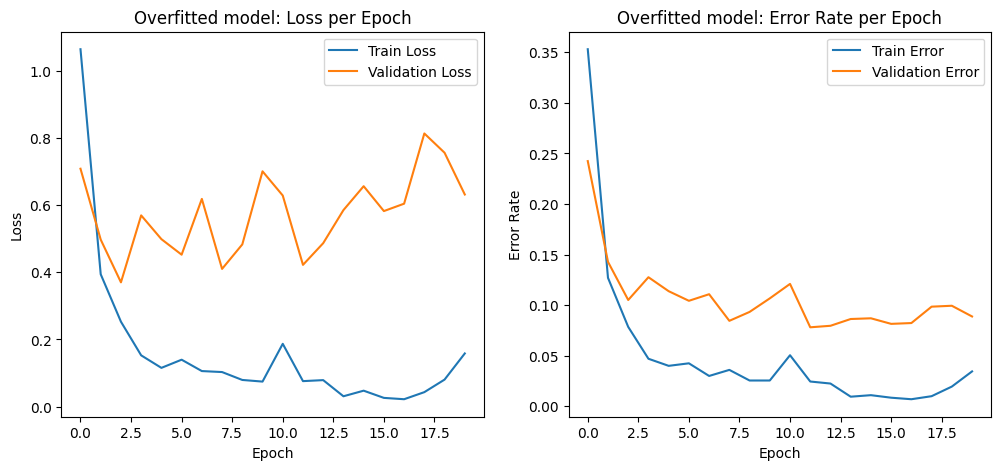

In [5]:
# "Overfitted" model
train_loader_small = get_subset_loader(train_dataset, subset_size=2000, batch_size=64)

model_overfit = FCNet(dropout_prob=0.0).to(device)
train_losses_of, test_losses_of, train_errors_of, test_errors_of = train_model(
    model_overfit,
    train_loader_small,
    test_loader,
    num_epochs=20,
    learning_rate=0.01,
    weight_decay=0.0
)

# Plot results
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses_of, label="Train Loss")
plt.plot(test_losses_of, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Overfitted model: Loss per Epoch")

plt.subplot(1,2,2)
plt.plot(train_errors_of, label="Train Error")
plt.plot(test_errors_of, label="Validation Error")
plt.xlabel("Epoch")
plt.ylabel("Error Rate")
plt.legend()
plt.title("Overfitted model: Error Rate per Epoch")
plt.show()

The graphs clearly display overfitting as the train loss/ error is much lower than the validation one. The up and down swings in the graph also suggest overfitting.

### 2.  Regularisation experiment:  ***12 marks***

Now select a type of regularisation (which may be L2, or dropout) and train your initial model with different amounts of regularisation.

A small amount of regularisation may improve the validation set performance of your overfitted model; too much regularisation may make performance on the validation set worse.

Train your model multiple times, applying different amounts of regularisation, and plot a graoph showing the effect of different amounts of regularisation.

Plot the amount of regularisation along the x axis, and the validation set performance (loss/error-rate) on the y axis.  How does regularisation affect the performance of your initial network, and what is the optimal amount?

[Training output trimmed — 59 lines]
...
Epoch [6/10], Train Loss: 0.3112, Train Error: 0.0988, Val Loss: 0.3268, Val Error: 0.1023
Epoch [7/10], Train Loss: 0.2983, Train Error: 0.0930, Val Loss: 0.3830, Val Error: 0.1189
Epoch [8/10], Train Loss: 0.2896, Train Error: 0.0915, Val Loss: 0.3608, Val Error: 0.1146
Epoch [9/10], Train Loss: 0.2966, Train Error: 0.0975, Val Loss: 0.3828, Val Error: 0.1244
Epoch [10/10], Train Loss: 0.3089, Train Error: 0.0965, Val Loss: 0.3058, Val Error: 0.0956


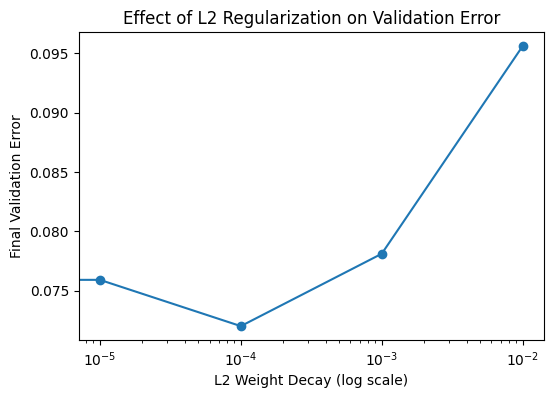

In [6]:
# Regularisation experiment.
train_loader_4000 = get_subset_loader(train_dataset, subset_size=4000, batch_size=64)

l2_values = [0.0, 1e-5, 1e-4, 1e-3, 1e-2]
num_epochs = 10
results = {}


for l2 in l2_values:
    print(f"\nTraining with L2 weight decay = {l2}")
    model_reg = FCNet(dropout_prob=0.0).to(device)
    _, _, _, test_errors = train_model(
        model_reg, 
        train_loader_4000, 
        test_loader, 
        num_epochs=num_epochs, 
        learning_rate=0.01, 
        weight_decay=l2
    )
    results[l2] = test_errors[-1]

# Plot how L2 effects the validation error.
plt.figure(figsize=(6,4))
plt.plot(l2_values, [results[l2] for l2 in l2_values], marker='o')
plt.xscale('log')
plt.xlabel("L2 Weight Decay (log scale)")
plt.ylabel("Final Validation Error")
plt.title("Effect of L2 Regularization on Validation Error")
plt.show()

At first, at validation error decreases, reaching the optimum value of 0.0001, after which the validation error increases with increaseing weight decay.

### 3.  Learning curve experiment:  ***12 marks***

Now train your model (with the amount of regularisation you selected) on different amounts of training data.

Plot the performance (loss/error-rate) of the model on the validation set against the size of the training set.
This is typically best done on a log-log plot.

Describe the approximate relationship between the training set size and loss / error-rate.  Does the network performance appear to improve as some power of the amount of data in the training set?  If so, by what power ?

For example, a very good rate of improvement is for error-rate to be proportional to $\dfrac{1}{\sqrt{n}}$ where $n$ is the training set size.  For your model, the rate of improvement of validation error with training set size may not be as fast as this (or it may, who knows?)  The aim of this exercise is to find out what it actually is.

[Training output trimmed — 85 lines]
...
Epoch [6/10], Train Loss: 0.1785, Train Error: 0.0471, Val Loss: 0.1919, Val Error: 0.0500
Epoch [7/10], Train Loss: 0.1748, Train Error: 0.0461, Val Loss: 0.1832, Val Error: 0.0476
Epoch [8/10], Train Loss: 0.1676, Train Error: 0.0441, Val Loss: 0.1844, Val Error: 0.0496
Epoch [9/10], Train Loss: 0.1678, Train Error: 0.0436, Val Loss: 0.1616, Val Error: 0.0402
Epoch [10/10], Train Loss: 0.1726, Train Error: 0.0457, Val Loss: 0.1609, Val Error: 0.0393


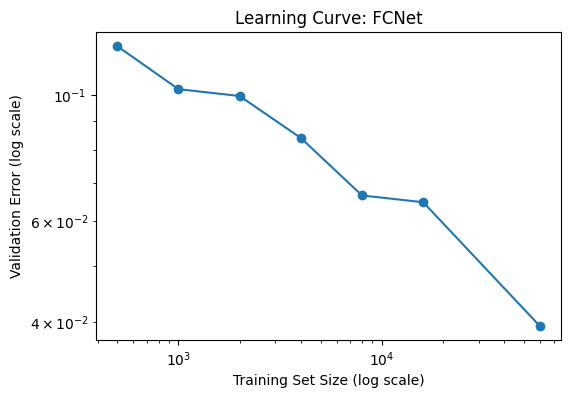

In [9]:
optimal_weight_decay = 0.0001
subset_sizes = [500, 1000, 2000, 4000, 8000, 16000, len(train_dataset)]
validation_errors_fc = {}

print("\n--- Learning Curve (FCNet) ---")
for size in subset_sizes:
    print(f"\nTraining with subset size = {size}")
    loader_subset = get_subset_loader(train_dataset, size)
    
    model_fc = FCNet(dropout_prob=0.0).to(device)
    _, _, _, test_errors_fc = train_model(
        model_fc,
        loader_subset,
        test_loader,
        num_epochs=10,
        learning_rate=0.01,
        weight_decay=optimal_weight_decay
    )
    validation_errors_fc[size] = test_errors_fc[-1]

# Plot the learning curve on log–log scale
plt.figure(figsize=(6,4))
x_vals = list(validation_errors_fc.keys())
y_vals = list(validation_errors_fc.values())

plt.loglog(x_vals, y_vals, marker='o')
plt.xlabel("Training Set Size (log scale)")
plt.ylabel("Validation Error (log scale)")
plt.title("Learning Curve: FCNet")
plt.show()

The validation error decreases as training set size increases.

### 4. Second model:   *** 14 marks ***

Devise what you believe to be a better neural network architecture for the problem (e.g. for MNIST you might use a fully-connected network for your initial model, and then try a convolutional net for your second model).

Repeat sections 2 (regularisation experiment), and determine whether it has better validation set performance than the first model, for an intermediate size of training set (e.g. 2000 or 4000 for the MNIST data).

Repeat section 3. Does your model have a different learning curve from the first? Plot the learning curves for the first and second model on the same graph, to compare them. Comment: is there a more rapid reduction of error-rate with training set size for your second model?  

[Training output trimmed — 16 lines]
...
Epoch [11/15], Train Loss: 0.1560, Train Error: 0.0473, Val Loss: 0.1436, Val Error: 0.0383
Epoch [12/15], Train Loss: 0.1658, Train Error: 0.0513, Val Loss: 0.1602, Val Error: 0.0493
Epoch [13/15], Train Loss: 0.1892, Train Error: 0.0605, Val Loss: 0.1637, Val Error: 0.0449
Epoch [14/15], Train Loss: 0.1674, Train Error: 0.0557, Val Loss: 0.1671, Val Error: 0.0441
Epoch [15/15], Train Loss: 0.1612, Train Error: 0.0477, Val Loss: 0.1696, Val Error: 0.0465


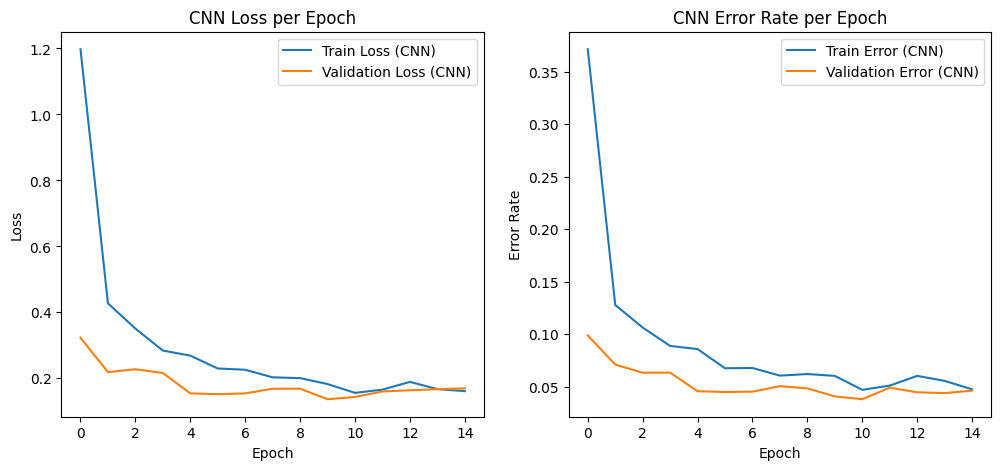

In [10]:
def CNNNet(dropout_prob=0.5):
    return nn.Sequential(
        nn.Conv2d(1, 32, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2, 2),
        nn.Conv2d(32, 64, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2, 2),
        nn.Flatten(),
        nn.Linear(64 * 7 * 7, 128),
        nn.ReLU(),
        nn.Dropout(dropout_prob),
        nn.Linear(128, 10)
    )

# Test the new model on testing set size = 4000 (intermediate size).
model_cnn = CNNNet(dropout_prob=0.5).to(device)
print("\nTraining CNN model on 4000 examples:")
train_losses_cnn, test_losses_cnn, train_errors_cnn, test_errors_cnn = train_model(model_cnn, train_loader_4000, test_loader, num_epochs=15, weight_decay=optimal_weight_decay)

# Plot training curves for CNN
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses_cnn, label="Train Loss (CNN)")
plt.plot(test_losses_cnn, label="Validation Loss (CNN)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("CNN Loss per Epoch")

plt.subplot(1,2,2)
plt.plot(train_errors_cnn, label="Train Error (CNN)")
plt.plot(test_errors_cnn, label="Validation Error (CNN)")
plt.xlabel("Epoch")
plt.ylabel("Error Rate")
plt.legend()
plt.title("CNN Error Rate per Epoch")
plt.show()

[Training output trimmed — 85 lines]
...
Epoch [6/10], Train Loss: 0.1828, Train Error: 0.0539, Val Loss: 0.1125, Val Error: 0.0338
Epoch [7/10], Train Loss: 0.1883, Train Error: 0.0543, Val Loss: 0.1148, Val Error: 0.0361
Epoch [8/10], Train Loss: 0.1808, Train Error: 0.0534, Val Loss: 0.0924, Val Error: 0.0287
Epoch [9/10], Train Loss: 0.1792, Train Error: 0.0521, Val Loss: 0.1145, Val Error: 0.0367
Epoch [10/10], Train Loss: 0.1784, Train Error: 0.0524, Val Loss: 0.1206, Val Error: 0.0353


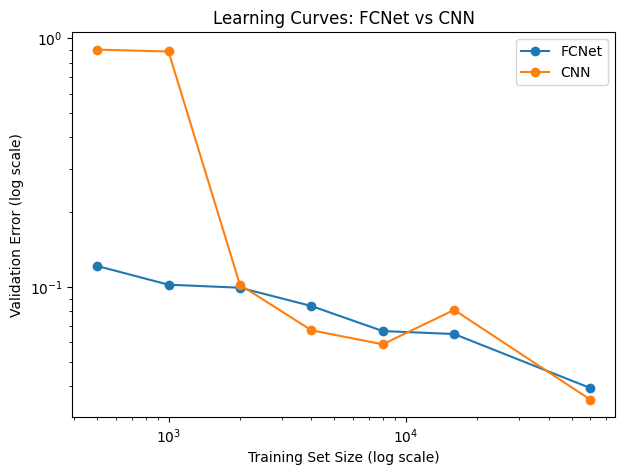

In [11]:
# Learning curve for CNN
validation_errors_cnn = {}

print("\n--- Learning Curve (CNN) ---")
for size in subset_sizes:
    print(f"\nTraining CNN with subset size = {size}")
    loader_subset = get_subset_loader(train_dataset, size)
    
    model_cnn_curve = CNNNet(dropout_prob=0.5).to(device)
    _, _, _, test_errors_cnn = train_model(
        model_cnn_curve,
        loader_subset,
        test_loader,
        num_epochs=10,
        learning_rate=0.01,
        weight_decay=optimal_weight_decay
    )
    validation_errors_cnn[size] = test_errors_cnn[-1]

# Plot FCNet and CNN on the same graph
plt.figure(figsize=(7,5))
x_vals = list(validation_errors_fc.keys())
y_fc  = [validation_errors_fc[x] for x in x_vals]
y_cnn = [validation_errors_cnn[x] for x in x_vals]

plt.loglog(x_vals, y_fc,  marker='o', label="FCNet")
plt.loglog(x_vals, y_cnn, marker='o', label="CNN")
plt.xlabel("Training Set Size (log scale)")
plt.ylabel("Validation Error (log scale)")
plt.title("Learning Curves: FCNet vs CNN")
plt.legend()
plt.show()

CNN starts at a very high validation error but as a dramatic fall at subset size = 2000. Ultimetaly, the CNN reaches a lower validation error at training_set_size = 60000 of 0.0353.